In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Photocurrent v/s Voltage Plot


In [84]:
file_path = "/content/PhotoConductivity-V_sweep.csv"
df = pd.read_csv(file_path)

print("Columns in CSV:")
print(df.columns.tolist())

Columns in CSV:
['Voltage (V)', 'Iph (0°) (mA)', 'Iph (30°) (mA)', 'Iph (60°) (mA)', 'Iph (90°) (mA)']


In [85]:
voltage_column = "Voltage (V)"

photocurrent_columns = {
    "0°": "Iph (0°) (mA)",
    "30°": "Iph (30°) (mA)",
    "60°": "Iph (60°) (mA)",
    "90°": "Iph (90°) (mA)"
}

V = df[voltage_column].values

## y = mx + c

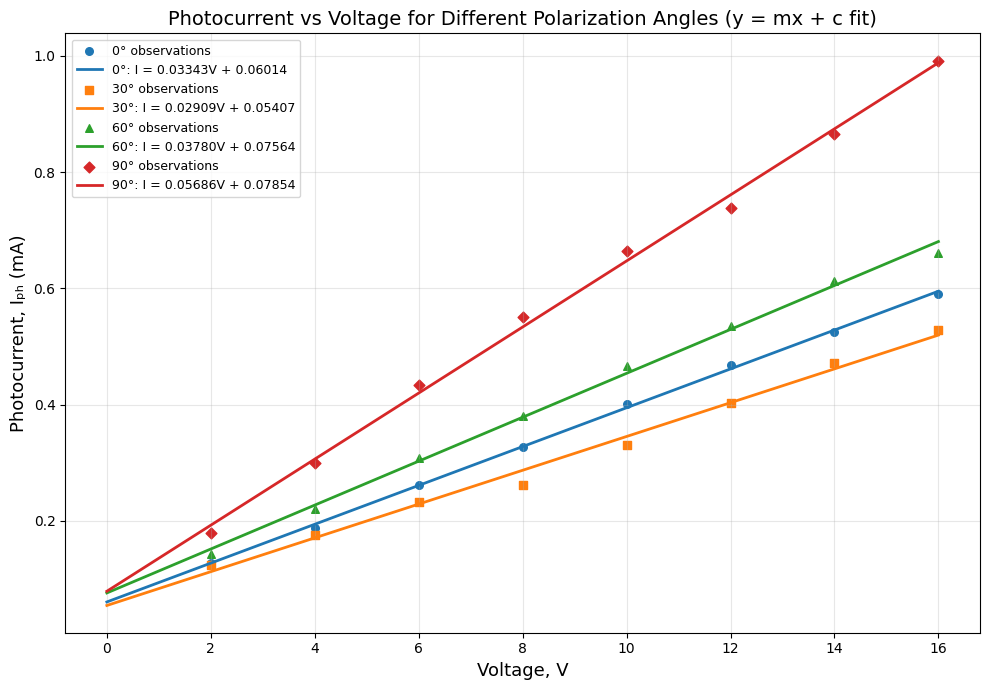

In [86]:
# Plot
plt.figure(figsize=(10, 7))

# Different marker/color for each angle
markers = ["o", "s", "^", "D"]
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

# Sample dimensions
A = 2.5e-5   # cm^2
d = 0.2      # cm

fit_results = {}

for (angle, column), marker, color in zip(
        photocurrent_columns.items(), markers, colors):

    Iph = df[column].values

    # Iph = m*V + c
    # cov contains the covariance matrix of m and c
    (m, c), cov = np.polyfit(V, Iph, 1, cov=True)

    # Deviations (1-sigma standard errors)
    m_error = np.sqrt(cov[0, 0])
    c_error = np.sqrt(cov[1, 1])

    # Calculate conductivity
    # m is in mA/V, so convert mA to A
    conductivity = (d / A) * m * 1e-3

    # Error in conductivity
    conductivity_error = (d / A) * m_error * 1e-3

    # Predicted values
    Iph_fit = m * V + c

    # Calculate R^2
    residuals = Iph - Iph_fit

    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((Iph - np.mean(Iph))**2)

    R2 = 1 - ss_res / ss_tot

    fit_results[angle] = {
        "slope": m,
        "slope_error": m_error,
        "intercept": c,
        "intercept_error": c_error,
        "conductivity": conductivity,
        "conductivity_error": conductivity_error,
        "R2": R2
    }

    # Plot experimental observations
    plt.scatter(
        V,
        Iph,
        color=color,
        marker=marker,
        s=30,
        label=f"{angle} observations"
    )

    # Plot fitted line
    V_fit = np.linspace(V.min() - 2, V.max(), 200)
    Iph_fit_line = m * V_fit + c

    plt.plot(
        V_fit,
        Iph_fit_line,
        color=color,
        linewidth=2,
        label=f"{angle}: I = {m:.5f}V + {c:.5f}"
    )

plt.xlabel("Voltage, V", fontsize=13)
plt.ylabel("Photocurrent, Iₚₕ (mA)", fontsize=13)

plt.title(
    "Photocurrent vs Voltage for Different Polarization Angles (y = mx + c fit)",
    fontsize=14
)

plt.grid(True, alpha=0.3)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()


In [87]:

# Print equations and fitting parameters

print("\n" + "=" * 60)
print("LINEAR FIT RESULTS")
print("=" * 60)

for angle, result in fit_results.items():

    m = result["slope"]
    m_error = result["slope_error"]
    c = result["intercept"]
    c_error = result["intercept_error"]
    conductivity = result["conductivity"]
    conductivity_error = result["conductivity_error"]
    R2 = result["R2"]

    print(f"\nAngle = {angle}")
    print("-" * 40)

    print(f"Slope        = {m:.6f} ± {m_error:.6f} mA/V")
    print(f"Intercept    = {c:.6f} ± {c_error:.6f} mA")
    print(f"Conductivity = {conductivity:.6f} ± {conductivity_error:.6f} S/cm")
    print(f"R²           = {R2:.6f}")

    print(f"Equation:")
    print(f"I_ph = ({m:.6f} ± {m_error:.6f}) V + ({c:.6f} ± {c_error:.6f})")


LINEAR FIT RESULTS

Angle = 0°
----------------------------------------
Slope        = 0.033429 ± 0.000395 mA/V
Intercept    = 0.060143 ± 0.003988 mA
Conductivity = 0.267429 ± 0.003159 S/cm
R²           = 0.999164
Equation:
I_ph = (0.033429 ± 0.000395) V + (0.060143 ± 0.003988)

Angle = 30°
----------------------------------------
Slope        = 0.029089 ± 0.001081 mA/V
Intercept    = 0.054071 ± 0.010916 mA
Conductivity = 0.232714 ± 0.008647 S/cm
R²           = 0.991785
Equation:
I_ph = (0.029089 ± 0.001081) V + (0.054071 ± 0.010916)

Angle = 60°
----------------------------------------
Slope        = 0.037804 ± 0.000919 mA/V
Intercept    = 0.075643 ± 0.009276 mA
Conductivity = 0.302429 ± 0.007348 S/cm
R²           = 0.996471
Equation:
I_ph = (0.037804 ± 0.000919) V + (0.075643 ± 0.009276)

Angle = 90°
----------------------------------------
Slope        = 0.056857 ± 0.001288 mA/V
Intercept    = 0.078536 ± 0.013008 mA
Conductivity = 0.454857 ± 0.010304 S/cm
R²           = 0.996931
Eq

## y = mx


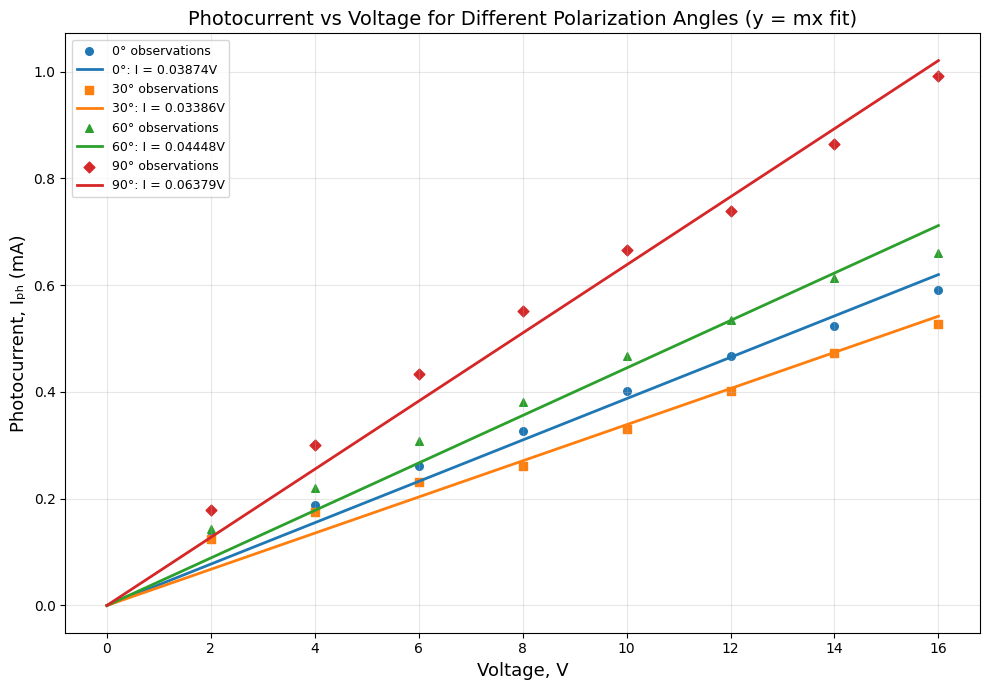

In [88]:
plt.figure(figsize=(10, 7))

for (angle, column), marker, color in zip(
        photocurrent_columns.items(), markers, colors):

    Iph = df[column].values

    # Iph = m*V
    # Least-squares fit constrained to pass through the origin
    m = np.sum(V * Iph) / np.sum(V**2)

    # Predicted values
    Iph_fit = m * V

    # Calculate R^2
    residuals = Iph - Iph_fit

    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((Iph - np.mean(Iph))**2)

    R2 = 1 - ss_res / ss_tot

    # Calculate deviation (1-sigma standard error) of slope
    n = len(V)
    degrees_of_freedom = n - 1

    residual_variance = ss_res / degrees_of_freedom

    m_error = np.sqrt(
        residual_variance / np.sum(V**2)
    )

    # Calculate conductivity
    # sigma = m*d/A
    #
    # m is in mA/V, so convert mA to A
    A = 2.5e-5  # cm^2
    d = 0.2     # cm

    conductivity = m * 1e-3 * d / A

    # Calculate error in conductivity
    conductivity_error = m_error * 1e-3 * d / A

    fit_results[angle] = {
        "slope": m,
        "slope_error": m_error,
        "conductivity": conductivity,
        "conductivity_error": conductivity_error,
        "R2": R2
    }

    # Plot experimental observations
    plt.scatter(
        V,
        Iph,
        color=color,
        marker=marker,
        s=30,
        label=f"{angle} observations"
    )

    # Plot fitted line
    V_fit = np.linspace(V.min() - 2, V.max(), 200)
    Iph_fit_line = m * V_fit

    plt.plot(
        V_fit,
        Iph_fit_line,
        color=color,
        linewidth=2,
        label=f"{angle}: I = {m:.5f}V"
    )

plt.xlabel("Voltage, V", fontsize=13)
plt.ylabel("Photocurrent, Iₚₕ (mA)", fontsize=13)

plt.title(
    "Photocurrent vs Voltage for Different Polarization Angles (y = mx fit)",
    fontsize=14
)

plt.grid(True, alpha=0.3)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()


In [89]:

# Print equations and fitting parameters

print("\n" + "=" * 60)
print("LINEAR FIT RESULTS")
print("=" * 60)
for angle, result in fit_results.items():

    m = result["slope"]
    m_error = result["slope_error"]
    conductivity = result["conductivity"]
    conductivity_error = result["conductivity_error"]
    R2 = result["R2"]

    print(f"\nAngle = {angle}")
    print("-" * 40)

    print(f"Slope        = {m:.6f} ± {m_error:.6f} mA/V")
    print(f"Intercept    = 0.000000 ± 0.000000 mA")
    print(f"Conductivity = {conductivity:.6f} ± {conductivity_error:.6f} S/cm")
    print(f"R²           = {R2:.6f}")

    print(f"Equation:")
    print(f"I_ph = ({m:.6f} ± {m_error:.6f}) V")


LINEAR FIT RESULTS

Angle = 0°
----------------------------------------
Slope        = 0.038735 ± 0.001035 mA/V
Intercept    = 0.000000 ± 0.000000 mA
Conductivity = 0.309882 ± 0.008277 S/cm
R²           = 0.967456
Equation:
I_ph = (0.038735 ± 0.001035) V

Angle = 30°
----------------------------------------
Slope        = 0.033860 ± 0.001024 mA/V
Intercept    = 0.000000 ± 0.000000 mA
Conductivity = 0.270882 ± 0.008194 S/cm
R²           = 0.958189
Equation:
I_ph = (0.033860 ± 0.001024) V

Angle = 60°
----------------------------------------
Slope        = 0.044478 ± 0.001341 mA/V
Intercept    = 0.000000 ± 0.000000 mA
Conductivity = 0.355824 ± 0.010729 S/cm
R²           = 0.957356
Equation:
I_ph = (0.044478 ± 0.001341) V

Angle = 90°
----------------------------------------
Slope        = 0.063787 ± 0.001439 mA/V
Intercept    = 0.000000 ± 0.000000 mA
Conductivity = 0.510294 ± 0.011513 S/cm
R²           = 0.978283
Equation:
I_ph = (0.063787 ± 0.001439) V


# Photocurrent v/s Angle


In [90]:
from scipy.optimize import curve_fit

In [91]:
file_path = "/content/PhotoConductivity-alpha_sweep.csv"

df = pd.read_csv(file_path)

print("Columns in CSV:")
print(df.columns.tolist())

angle = df["α (degree)"].values

voltage_columns = {
    "1 V": "Iph(1V)",
    "8 V": "Iph(8V)",
    "4 V": "Iph(4V)",
    "16 V": "Iph(16V)"
}

Columns in CSV:
['α (degree)', 'Iph(1V)', 'Iph(8V)', 'Iph(4V)', 'Iph(16V)']


In [92]:
# Cosine-squared model
# I = C + A cos²(alpha - phi)

def cosine_squared(angle, C, A, phi):

    return C + A * np.cos(
        np.deg2rad(angle - phi)
    )**2

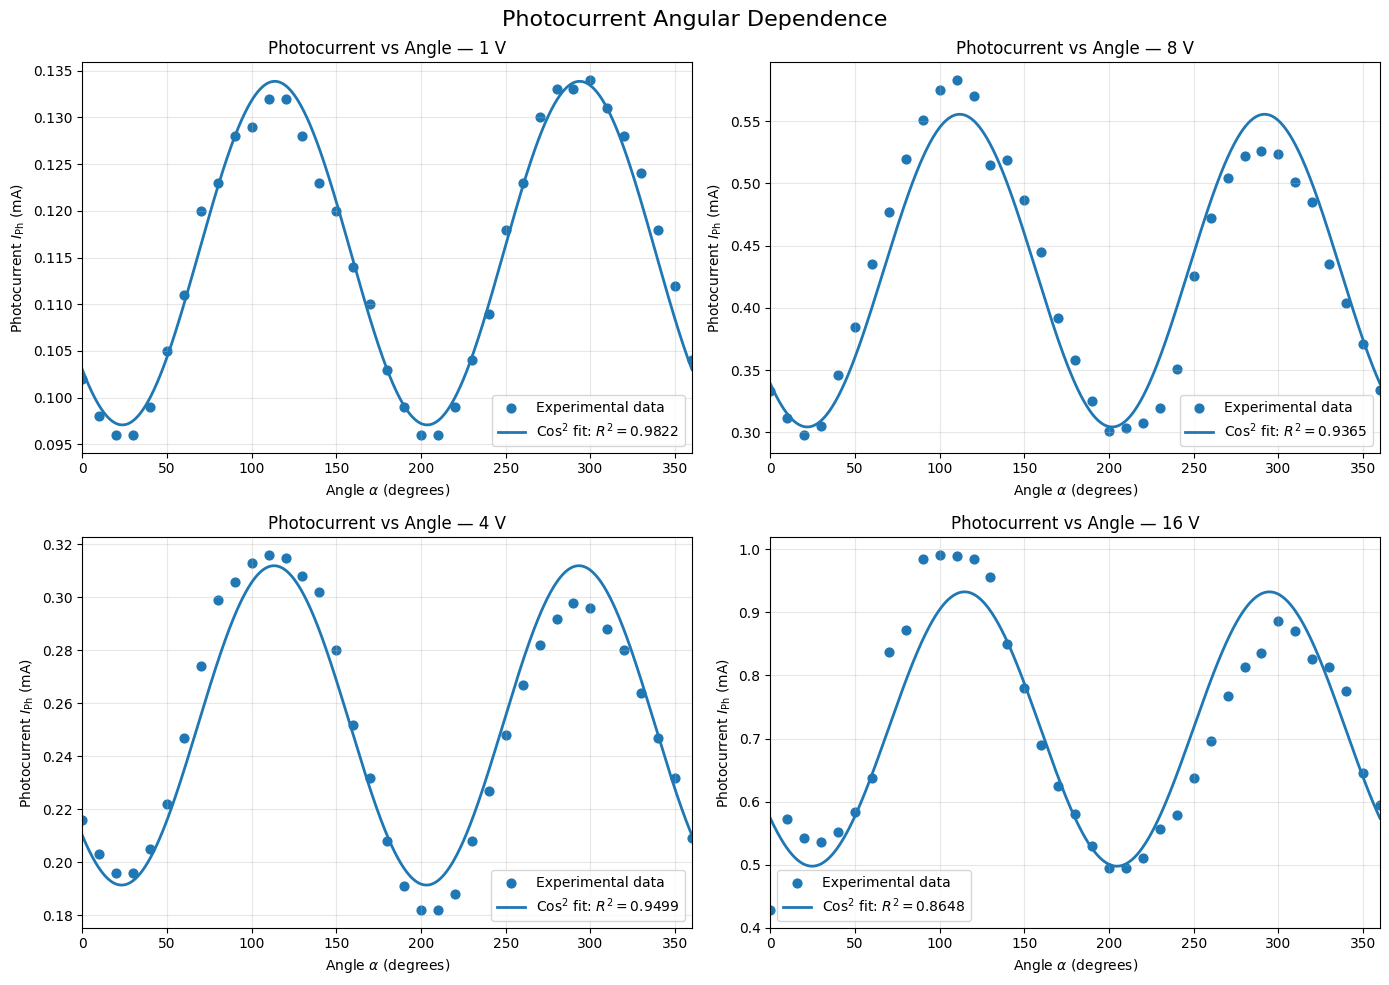

In [93]:
# Fit and plot

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

results = []

for ax, (voltage, column) in zip(axes, voltage_columns.items()):

    Iph = df[column].values

    # Initial guesses
    C_initial = np.min(Iph)
    A_initial = np.max(Iph) - np.min(Iph)
    phi_initial = -60

    # Fit COS² model
    # A is constrained to be positive.
    bounds_cos2 = (
        [-np.inf, 0, -180],
        [np.inf, 2 * A_initial, 180]
    )

    params_cos2, covariance_cos2 = curve_fit(
        cosine_squared,
        angle,
        Iph,
        p0=[C_initial, A_initial, phi_initial],
        bounds=bounds_cos2,
        maxfev=50000
    )

    # Fitted parameters
    C2, A2, phi2 = params_cos2

    # --------------------------------------------------
    # Parameter uncertainties from covariance matrix
    # --------------------------------------------------

    sigma_C2 = np.sqrt(covariance_cos2[0, 0])
    sigma_A2 = np.sqrt(covariance_cos2[1, 1])
    sigma_phi2 = np.sqrt(covariance_cos2[2, 2])

    # Predicted values
    Iph_cos2 = cosine_squared(angle, C2, A2, phi2)

    # Calculate R²
    ss_total = np.sum((Iph - np.mean(Iph))**2)
    ss_res_cos2 = np.sum((Iph - Iph_cos2)**2)
    R2_cos2 = 1 - ss_res_cos2 / ss_total

    # Generate smooth curves
    angle_smooth = np.linspace(0, 360, 1000)
    fit_smooth_cos2 = cosine_squared(
        angle_smooth,
        C2,
        A2,
        phi2
    )

    # Plot experimental observations
    ax.scatter(
        angle,
        Iph,
        s=40,
        label="Experimental data"
    )

    # Plot COS² fit
    ax.plot(
        angle_smooth,
        fit_smooth_cos2,
        linewidth=2,
        label=(
            r"Cos$^2$ fit: "
            f"$R^2={R2_cos2:.4f}$"
        )
    )

    # Plot formatting
    ax.set_title(
        f"Photocurrent vs Angle — {voltage}"
    )
    ax.set_xlabel(
        r"Angle $\alpha$ (degrees)"
    )
    ax.set_ylabel(
        r"Photocurrent $I_{\rm Ph}$ (mA)"
    )
    ax.set_xlim(0, 360)

    ax.grid(True, alpha=0.3)
    ax.legend()

    # Store results
    results.append({
        "Voltage": voltage,
        "Model": "Cos²",

        "Offset C (mA)": C2,
        "Offset C Error (mA)": sigma_C2,

        "Amplitude A (mA)": A2,
        "Amplitude A Error (mA)": sigma_A2,

        "Phase φ (degree)": phi2,
        "Phase φ Error (degree)": sigma_phi2,

        "R²": R2_cos2,

        "Covariance Matrix": covariance_cos2
    })


fig.suptitle(
    "Photocurrent Angular Dependence",
    fontsize=16
)

plt.tight_layout()
plt.show()



In [94]:

# ------------------------------------------------------
# Print COS² FIT RESULTS
# ------------------------------------------------------

print("=" * 70)
print("COS² FIT RESULTS")
print("=" * 70)

for result in results:

    print(
        f"\nVoltage = {result['Voltage']}"
    )

    print(
        f"Offset C      = "
        f"{result['Offset C (mA)']:.6f} "
        f"± "
        f"{result['Offset C Error (mA)']:.6f} mA"
    )

    print(
        f"Amplitude A   = "
        f"{result['Amplitude A (mA)']:.6f} "
        f"± "
        f"{result['Amplitude A Error (mA)']:.6f} mA"
    )

    print(
        f"Phase phi     = "
        f"{result['Phase φ (degree)']:.4f} "
        f"± "
        f"{result['Phase φ Error (degree)']:.4f}°"
    )

    print(
        f"R²            = "
        f"{result['R²']:.6f}"
    )

    print("\nEquation:")

    print(
        f"I_ph = "
        f"({result['Offset C (mA)']:.6f} "
        f"± "
        f"{result['Offset C Error (mA)']:.6f}) "
        f"+ "
        f"({result['Amplitude A (mA)']:.6f} "
        f"± "
        f"{result['Amplitude A Error (mA)']:.6f}) "
        f"* cos²(alpha - "
        f"({result['Phase φ (degree)']:.4f} "
        f"± "
        f"{result['Phase φ Error (degree)']:.4f})°)"
    )

    print("\nCovariance matrix:")
    print(result["Covariance Matrix"])

COS² FIT RESULTS

Voltage = 1 V
Offset C      = 0.097078 ± 0.000514 mA
Amplitude A   = 0.036788 ± 0.000849 mA
Phase phi     = -66.3407 ± 0.6600°
R²            = 0.982211

Equation:
I_ph = (0.097078 ± 0.000514) + (0.036788 ± 0.000849) * cos²(alpha - (-66.3407 ± 0.6600)°)

Covariance matrix:
[[ 2.63910036e-07 -3.54275701e-07 -1.27743636e-05]
 [-3.54275701e-07  7.21393748e-07  1.47038747e-05]
 [-1.27743636e-05  1.47038747e-05  4.35617513e-01]]

Voltage = 8 V
Offset C      = 0.304449 ± 0.006781 mA
Amplitude A   = 0.251091 ± 0.011214 mA
Phase phi     = -68.1568 ± 1.2810°
R²            = 0.936531

Equation:
I_ph = (0.304449 ± 0.006781) + (0.251091 ± 0.011214) * cos²(alpha - (-68.1568 ± 1.2810)°)

Covariance matrix:
[[ 4.59785089e-05 -6.16786899e-05 -3.19367651e-04]
 [-6.16786899e-05  1.25753329e-04  3.77628780e-04]
 [-3.19367651e-04  3.77628780e-04  1.64093456e+00]]

Voltage = 4 V
Offset C      = 0.191402 ± 0.002874 mA
Amplitude A   = 0.120577 ± 0.004752 mA
Phase phi     = -66.7871 ± 1.1276°

# Photocurrent v/s Irradiance

In [95]:
file_path = "/content/PhotoConductivity-alpha_sweep.csv"
df = pd.read_csv(file_path)

print("Columns in CSV:")
print(df.columns.tolist())

angle_column = "α (degree)"

photocurrent_columns = {
    "1 V": "Iph(1V)",
    "8 V": "Iph(8V)",
    "4 V": "Iph(4V)",
    "16 V": "Iph(16V)"
}

alpha = df[angle_column].values

Columns in CSV:
['α (degree)', 'Iph(1V)', 'Iph(8V)', 'Iph(4V)', 'Iph(16V)']


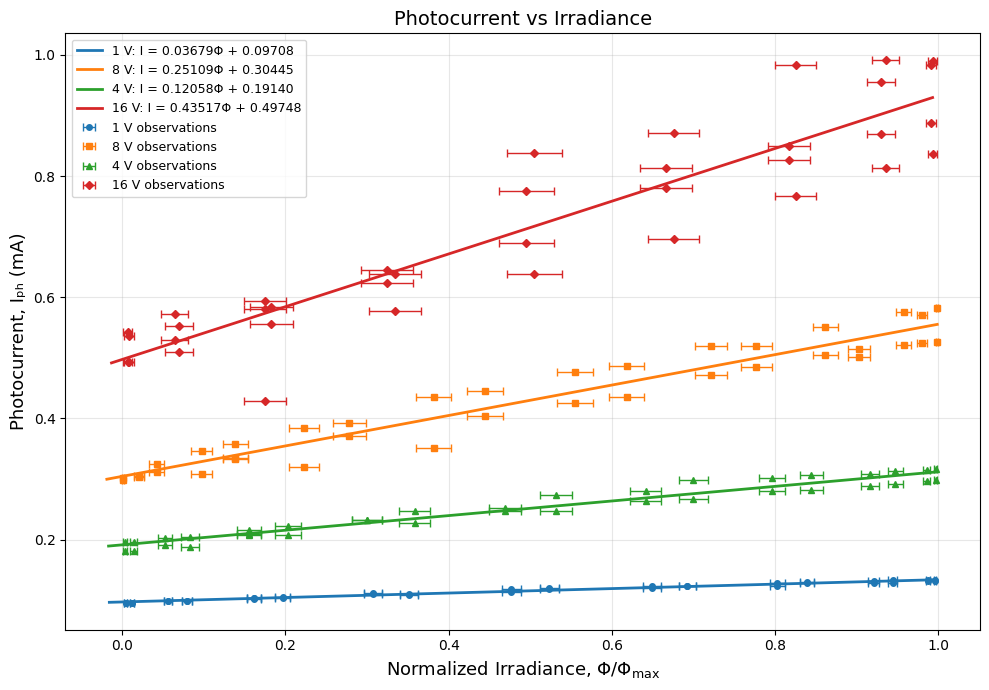

In [96]:
# ============================================================
# Irradiance parameters
# ============================================================

# Normalized irradiance:
# Phi / Phi_max = cos^2(alpha - phi)

phi_0 = 1.0
D = 1.0


# ============================================================
# Define cosine-squared model
# ============================================================

def cosine_squared(alpha, C, A, phi):
    return C + A * np.cos(
        np.deg2rad(alpha - phi)
    )**2


# ============================================================
# Plot Iph vs Irradiance
# ============================================================

plt.figure(figsize=(10, 7))

markers = ["o", "s", "^", "D"]
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

fit_results = {}

for (voltage, column), marker, color in zip(
        photocurrent_columns.items(), markers, colors):

    Iph = df[column].values


    # ========================================================
    # Fit Iph vs alpha
    # ========================================================

    C_initial = np.min(Iph)
    A_initial = np.max(Iph) - np.min(Iph)

    phi_initial = -60

    params, covariance = curve_fit(
        cosine_squared,
        alpha,
        Iph,
        p0=[
            C_initial,
            A_initial,
            phi_initial
        ],
        bounds=(
            [-np.inf, 0, -180],
            [np.inf, 2 * A_initial, 180]
        ),
        maxfev=50000
    )

    C, A, phi = params


    # ========================================================
    # Statistical errors from covariance matrix
    # ========================================================

    C_error = np.sqrt(covariance[0, 0])
    A_error = np.sqrt(covariance[1, 1])
    phi_error = np.sqrt(covariance[2, 2])


    # ========================================================
    # Calculate fitted values
    # ========================================================

    Iph_fit = cosine_squared(
        alpha,
        C,
        A,
        phi
    )


    # ========================================================
    # Calculate R^2
    # ========================================================

    residuals = Iph - Iph_fit

    ss_res = np.sum(residuals**2)

    ss_tot = np.sum(
        (Iph - np.mean(Iph))**2
    )

    R2_angle = 1 - ss_res / ss_tot


    # ========================================================
    # Calculate irradiance
    #
    # Phi = Phi_0 * D * cos^2(alpha - phi)
    # ========================================================

    theta = alpha - phi

    irradiance = (
        phi_0
        * D
        * np.cos(np.deg2rad(theta))**2
    )


    # ========================================================
    # Propagate phase uncertainty into irradiance uncertainty
    #
    # dPhi/dphi =
    # Phi_0 * D * sin(2theta) * pi/180
    # ========================================================

    irradiance_error = (
        phi_0
        * D
        * np.abs(
            np.sin(
                np.deg2rad(2 * theta)
            )
        )
        * np.deg2rad(1)
        * phi_error
    )


    # ========================================================
    # Fit Iph vs irradiance
    #
    # Iph = m*Phi + c
    # ========================================================

    (m, c), cov = np.polyfit(
        irradiance,
        Iph,
        1,
        cov=True
    )


    # ========================================================
    # Errors in slope and intercept
    # ========================================================

    m_error = np.sqrt(
        cov[0, 0]
    )

    c_error = np.sqrt(
        cov[1, 1]
    )


    # ========================================================
    # Predicted photocurrent
    # ========================================================

    Iph_irradiance_fit = (
        m * irradiance + c
    )


    # ========================================================
    # R^2 for Iph vs irradiance
    # ========================================================

    residuals_irradiance = (
        Iph - Iph_irradiance_fit
    )

    ss_res_irradiance = np.sum(
        residuals_irradiance**2
    )

    ss_tot_irradiance = np.sum(
        (Iph - np.mean(Iph))**2
    )

    R2_irradiance = (
        1
        - ss_res_irradiance
        / ss_tot_irradiance
    )


    # ========================================================
    # Store results
    # ========================================================

    fit_results[voltage] = {
        "C": C,
        "C_error": C_error,
        "A": A,
        "A_error": A_error,
        "phi": phi,
        "phi_error": phi_error,
        "R2_angle": R2_angle,
        "slope": m,
        "slope_error": m_error,
        "intercept": c,
        "intercept_error": c_error,
        "R2_irradiance": R2_irradiance
    }


    # ========================================================
    # Plot observations
    # ========================================================

    plt.errorbar(
        irradiance,
        Iph,
        xerr=irradiance_error,
        color=color,
        marker=marker,
        linestyle="none",
        markersize=4,
        capsize=3,
        capthick=1,
        elinewidth=1,
        zorder=3,
        label=f"{voltage} observations"
    )


    # ========================================================
    # Plot fitted line
    # ========================================================

    irradiance_fit = np.linspace(
        irradiance.min() - 0.02,
        irradiance.max(),
        200
    )

    Iph_fit_line = (
        m * irradiance_fit + c
    )

    plt.plot(
        irradiance_fit,
        Iph_fit_line,
        color=color,
        linewidth=2,
        label=(
            f"{voltage}: "
            f"I = {m:.5f}Φ + {c:.5f}"
        )
    )


# ============================================================
# Plot formatting
# ============================================================

plt.xlabel(
    r"Normalized Irradiance, $\Phi/\Phi_{\max}$",
    fontsize=13
)

plt.ylabel(
    "Photocurrent, Iₚₕ (mA)",
    fontsize=13
)

plt.title(
    "Photocurrent vs Irradiance",
    fontsize=14
)

plt.grid(
    True,
    alpha=0.3
)

plt.legend(
    fontsize=9
)

plt.tight_layout()

plt.show()


In [97]:


# ============================================================
# Print results
# ============================================================

print("\n" + "=" * 70)
print("PHOTOCURRENT vs IRRADIANCE FIT RESULTS")
print("=" * 70)

for voltage, result in fit_results.items():

    print(f"\nVoltage = {voltage}")

    print("-" * 50)

    print(
        f"Angular offset C     = "
        f"{result['C']:.6f} ± "
        f"{result['C_error']:.6f} mA"
    )

    print(
        f"Angular amplitude A  = "
        f"{result['A']:.6f} ± "
        f"{result['A_error']:.6f} mA"
    )

    print(
        f"Phase φ              = "
        f"{result['phi']:.6f} ± "
        f"{result['phi_error']:.6f}°"
    )

    print(
        f"Angular fit R²       = "
        f"{result['R2_angle']:.6f}"
    )

    print()

    print(
        f"Irradiance slope m   = "
        f"{result['slope']:.6f} ± "
        f"{result['slope_error']:.6f} mA"
    )

    print(
        f"Intercept c          = "
        f"{result['intercept']:.6f} ± "
        f"{result['intercept_error']:.6f} mA"
    )

    print(
        f"Irradiance fit R²    = "
        f"{result['R2_irradiance']:.6f}"
    )

    print()

    print("Equation:")

    print(
        f"I_ph = "
        f"({result['slope']:.6f} ± "
        f"{result['slope_error']:.6f}) Φ + "
        f"({result['intercept']:.6f} ± "
        f"{result['intercept_error']:.6f})"
    )


PHOTOCURRENT vs IRRADIANCE FIT RESULTS

Voltage = 1 V
--------------------------------------------------
Angular offset C     = 0.097078 ± 0.000514 mA
Angular amplitude A  = 0.036788 ± 0.000849 mA
Phase φ              = -66.340669 ± 0.660013°
Angular fit R²       = 0.982211

Irradiance slope m   = 0.036788 ± 0.000837 mA
Intercept c          = 0.097078 ± 0.000506 mA
Irradiance fit R²    = 0.982211

Equation:
I_ph = (0.036788 ± 0.000837) Φ + (0.097078 ± 0.000506)

Voltage = 8 V
--------------------------------------------------
Angular offset C     = 0.304449 ± 0.006781 mA
Angular amplitude A  = 0.251091 ± 0.011214 mA
Phase φ              = -68.156836 ± 1.280990°
Angular fit R²       = 0.936531

Irradiance slope m   = 0.251091 ± 0.011049 mA
Intercept c          = 0.304449 ± 0.006679 mA
Irradiance fit R²    = 0.936531

Equation:
I_ph = (0.251091 ± 0.011049) Φ + (0.304449 ± 0.006679)

Voltage = 4 V
--------------------------------------------------
Angular offset C     = 0.191402 ± 0.0028